In [5]:
import pandas as pd
import re
import glob
import os

def parse_beacon_line(hex_string, max_repeaters=4):
    pos = 46
    repeaters = []

    while pos + 14 <= len(hex_string):
        repeater_id = hex_string[pos:pos+8]
        pos += 8
        pos += 4  # skip
        if pos + 2 > len(hex_string):
            break
        distance = hex_string[pos:pos+2]
        pos += 2
        repeaters.append((repeater_id, int(distance, 16)))
        if len(repeaters) >= max_repeaters:
            break
        if len(hex_string) - pos < 14:
            break

    while len(repeaters) < max_repeaters:
        repeaters.append(("00000000", 0))

    return repeaters


# 1つの .log ファイルを処理する関数
def process_log_file(log_path):
    with open(log_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    records = []

    for line in lines:
        match = re.match(r"\[(.*?)\]\s*:(\S+)", line)
        if match:
            timestamp = match.group(1)
            hex_data = match.group(2)

            repeaters = parse_beacon_line(hex_data)

            for rep_id, dist in repeaters:
                if rep_id != "00000000":
                    records.append({
                        "timestamp": timestamp,
                        "beacon_id": rep_id,
                        "distance": dist
                    })

    if len(records) == 0:
        return pd.DataFrame()

    df = pd.DataFrame(records)

    # pivot
    df = df.pivot_table(index="timestamp", columns="beacon_id", values="distance", aggfunc='first')
    df = df.reset_index()
    df.insert(0, 'index', range(len(df)))
    cols = ['index', 'timestamp'] + [c for c in df.columns if c not in ('index', 'timestamp')]
    df = df[cols]
    df.columns.name = None

    # 欠損を前方向補完
    df = df.ffill()

    return df


# フォルダ内の全 .log を処理する関数
def process_all_logs(folder_path):
    results = {}
    log_files = glob.glob(os.path.join(folder_path, "*.log"))

    for log_path in log_files:
        print(f"Processing: {log_path}")
        df = process_log_file(log_path)
        results[os.path.basename(log_path)] = df

    return results

# 保存

all_results = process_all_logs(".")
for fname, df in all_results.items():
    base, _ = os.path.splitext(fname)   # "aaa.log" → ("aaa", ".log")
    # df.to_csv(f"{base}.csv", index=False)


print(df.index)

df.head()

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# --- 中継器の座標 ---（必要なら変更）
repeater_positions = {
    '810257F7': (90, 0),
    '81025919': (50, 0),
    '81025B89': (30, 0),
    '810B3B76': (0, 0)
}

# --- 三辺測量 (最小二乗) ---
def trilaterate(positions, distances):
    def loss(xy):
        return sum((np.linalg.norm(xy - np.array(p)) - d)**2 
                   for p, d in zip(positions, distances))
    x0 = np.mean(positions, axis=0)  # 初期値
    result = minimize(loss, x0, method='L-BFGS-B')
    return result.x if result.success else None


# --- 新形式 df に対して測位 ---
def estimate_positions(df, repeater_positions):
    positions = []

    for i in range(len(df)):
        row = df.iloc[i]

        # その行で利用できる repeater と距離
        available = []
        for rep, pos in repeater_positions.items():
            if rep in row and not np.isnan(row[rep]):
                available.append((rep, row[rep]))

        # 3つ以上あれば trilateration
        if len(available) >= 3:
            coords = [repeater_positions[r] for r, _ in available]
            dists = [d for _, d in available]
            est = trilaterate(coords, dists)
            positions.append(est)
            continue

        # 足りない → 前後で補完
        est = None

        # forward search
        for j in range(i+1, len(df)):
            row2 = df.iloc[j]
            avail2 = [(r, row2[r]) for r in repeater_positions if r in row2 and not np.isnan(row2[r])]
            if len(avail2) >= 3:
                coords = [repeater_positions[r] for r, _ in avail2]
                dists = [d for _, d in avail2]
                est = trilaterate(coords, dists)
                break

        # backward search
        if est is None:
            for j in range(i-1, -1, -1):
                row2 = df.iloc[j]
                avail2 = [(r, row2[r]) for r in repeater_positions if r in row2 and not np.isnan(row2[r])]
                if len(avail2) >= 3:
                    coords = [repeater_positions[r] for r, _ in avail2]
                    dists = [d for _, d in avail2]
                    est = trilaterate(coords, dists)
                    break

        positions.append(est)

    return np.array(positions, dtype=object)


# --- 実行 ---
pos = estimate_positions(df, repeater_positions)

# 実際に座標が計算できたものだけ抽出
xy_array = np.array([p for p in pos if p is not None])


# --- プロット ---
fig, ax = plt.subplots(figsize=(8, 8))

# repeater plot
for r_id, (x, y) in repeater_positions.items():
    ax.plot(x, y, 'bo')
    ax.text(x+0.2, y+0.2, r_id[-4:])

# beacon path plot
if len(xy_array) > 0:
    # ax.plot(xy_array[:, 0], xy_array[:, 1], 'r.-', label="Beacon Path")
    ax.plot(xy_array[:100, 0], xy_array[:100, 1], 'r.-',label="Beacon Path(1)")
    ax.plot(xy_array[100:200, 0], xy_array[100:200, 1], 'g.-',label="Beacon Path(2)")
    ax.plot(xy_array[200:300, 0], xy_array[200:300, 1], 'm.-', label="Beacon Path(3)")
    ax.plot(xy_array[300:, 0], xy_array[300:, 1], 'c.-', label="Beacon Path(4)")
    

ax.set_title("Beacon Location (Trilateration)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.axis("equal")
ax.grid()
plt.legend()
plt.show()


In [8]:
df = pd.read_csv("kannno1.csv")

print(df.isnull().sum())
# 線形補完
df = df.interpolate(method='linear', limit_direction='both')


index         0
timestamp     0
810257F7     45
81025919     22
81025B89      1
810B3B76      0
dtype: int64


C:\Users\is0671vx\AppData\Local\Temp\ipykernel_10020\913644962.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear', limit_direction='both')


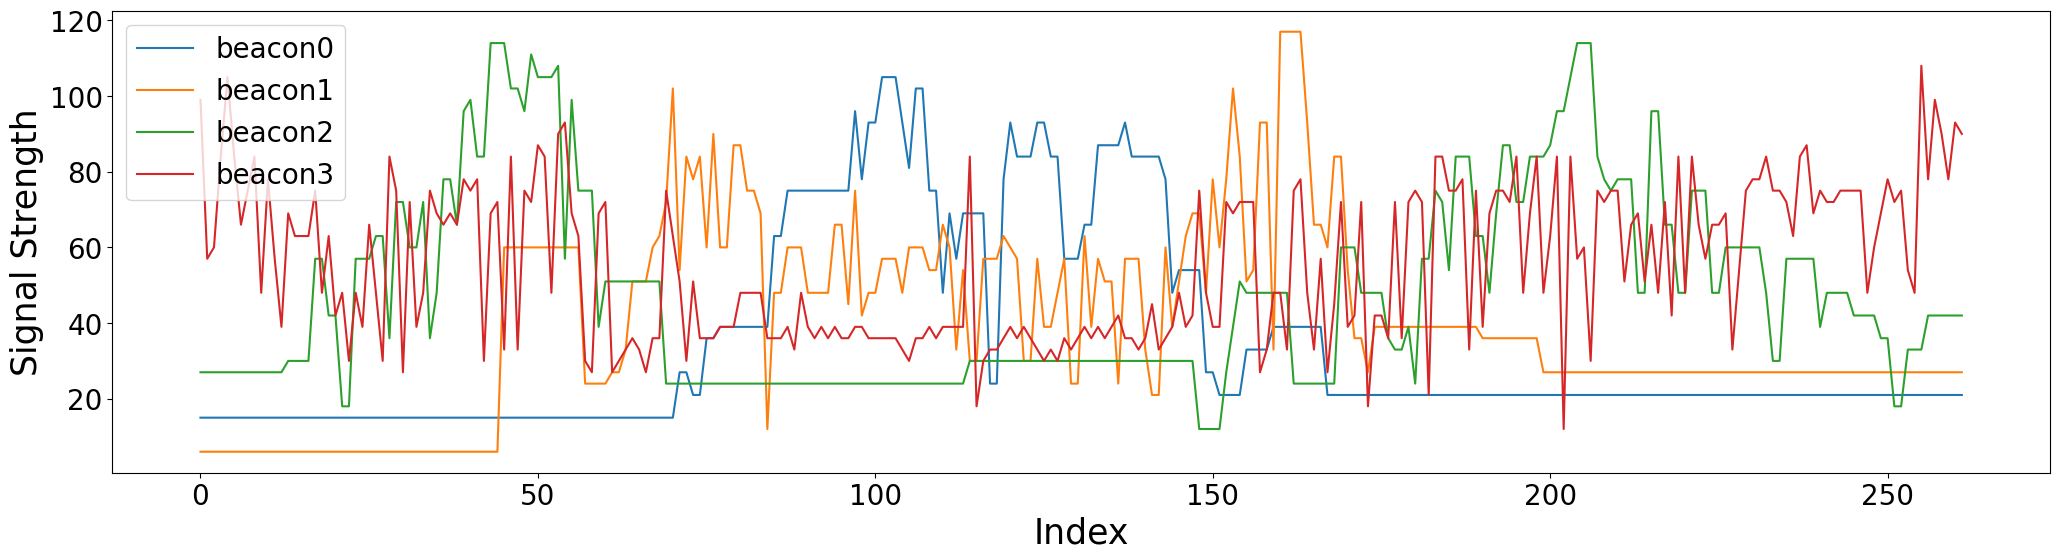

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(25, 6))
plt.plot(df.index, df['810257F7'], label='beacon0')
plt.plot(df.index, df['81025919'], label='beacon1')
plt.plot(df.index, df['81025B89'], label='beacon2')
plt.plot(df.index, df['810B3B76'], label='beacon3')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlabel('Index',fontsize=25)
plt.ylabel('Signal Strength', fontsize=25)
plt.legend(fontsize=20)
plt.show()

In [10]:
df.drop(columns='index').describe()
df.drop(columns='index').describe().to_excel("kannno1_summary.xlsx")

: 

: 

: 